In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 데이터 셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt # 학습과정 loss와 acc 시각화

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

# 학습셋(6만개) -> 검증셋(1만개)+훈련셋(5만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

# 학습셋(5만개: fit용), 검증셋(1만:fit용), 테스트셋(1만, 평가용)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

# 입력(독립) 변수 (n, 28,28) -> n, 784 -> 실수형변환 -> 스케일조정(255.0으로 나눠서)
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
print(train_X.shape, val_X.shape, test_X.shape)

# 훈련셋5만개, -> 40000개, 테스트셋 1만개 -> 9000개 추출 (목적: 학습시간 고려하되 모든 데이터 이용)
train_idx = np.random.choice(50000, 50000)
val_idx = np.random.choice(10000, 10000)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X = val_X[val_idx]
y_val = y_val[val_idx]
print(train_X.shape, y_train.shape, val_X.shape, y_val.shape, test_X.shape, y_test.shape)

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1568, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=784, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(units=196, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(units=49, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()

# 타겟(종속)변수의 원핫코딩
train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val, 10)
test_Y = to_categorical(y_test, 10)
print(y_train[:2])
print(train_Y[:2])

train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

(50000, 28, 28) (50000,)
(10000, 28, 28) (10000,)
(10000, 28, 28) (10000,)
(50000, 784) (10000, 784) (10000, 784)
(50000, 784) (50000,) (10000, 784) (10000,) (10000, 784) (10000,)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1568)              1230880   
                                                                 
 dropout (Dropout)           (None, 1568)              0         
                                                                 
 dense_1 (Dense)             (None, 784)               1230096   
                                                                 
 dropout_1 (Dropout)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 196)               153860    
                                                                 
 dropout

((50000, 784),
 (50000, 10),
 (10000, 784),
 (10000, 10),
 (10000, 784),
 (10000, 10))

In [4]:
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy', # sparce_categorical_crossentropy
             optimizer=Adam(learning_rate=0.01),
             metrics=['accuracy', # 정확도
                      metrics.Recall(), # 재현율(실제값 중심)
                      metrics.Precision()]) # 정밀도(예측값 중심)

hist = model.fit(train_X, train_Y, # 훈련데이터
                epochs=30, # 학습횟수
                batch_size=10000, # 한번에 읽어들이는 데이터 양
                validation_data=(val_X, val_Y), # 검증 데이터
#                 validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
                verbose=1 # 학습 로그 출력 여부 (0: 출력x, 1:출력o(default), 2:출력자세히o)
                )

Epoch 1/30
5/5 [==============================] - 6s 1s/step - loss: 2.8530 - accuracy: 0.1397 - recall: 0.0426 - precision: 0.1697 - val_loss: 2.4767 - val_accuracy: 0.1092 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00
Epoch 2/30
5/5 [==============================] - 4s 889ms/step - loss: 2.3689 - accuracy: 0.1326 - recall: 2.0000e-05 - precision: 0.2500 - val_loss: 2.2451 - val_accuracy: 0.2939 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00
Epoch 3/30
5/5 [==============================] - 4s 895ms/step - loss: 2.2354 - accuracy: 0.1848 - recall: 0.0000e+00 - precision: 0.0000e+00 - val_loss: 2.1067 - val_accuracy: 0.2874 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00
Epoch 4/30
5/5 [==============================] - 4s 897ms/step - loss: 2.1149 - accuracy: 0.2417 - recall: 0.0000e+00 - precision: 0.0000e+00 - val_loss: 1.9819 - val_accuracy: 0.3525 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00
Epoch 5/30
5/5 [==============================] - 4s 871ms/step

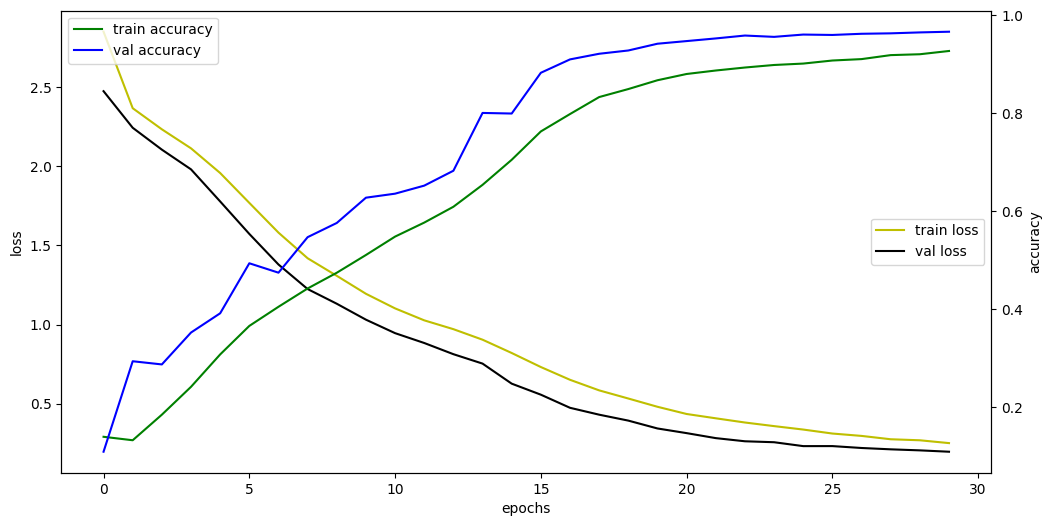

In [5]:
hist.history.keys()
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'k', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
# acc_ax.plot(hist.history['recall_3'], 'g', label='train recall')
# acc_ax.plot(hist.history['precision_3'], 'g', label='train precision')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
# acc_ax.plot(hist.history['val_recall_3'], 'b', label='val recall')
# acc_ax.plot(hist.history['val_precision_3'], 'b', label='val precision')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [6]:
# 모델 평가하기
loss_and_mertics = model.evaluate(test_X, test_Y, batch_size=1000, verbose=1)

# 교차표
y_hat = model.predict(test_X).argmax(axis=1)
print(y_hat)
pd.crosstab(y_test.reshape(-1), y_hat,
           rownames=['실제값'],
           colnames=['예측값'])

313/313 [==============================] - 2s 6ms/step
[7 2 1 ... 4 5 6]


예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,958,0,1,2,0,5,12,0,2,0
1,0,1122,5,1,0,1,2,0,4,0
2,3,8,984,14,1,0,4,12,5,1
3,0,0,6,954,0,18,0,7,23,2
4,0,0,9,0,938,0,10,3,0,22
5,4,0,0,5,4,869,1,0,6,3
6,6,2,2,1,6,8,931,0,2,0
7,0,3,12,2,1,1,0,992,2,15
8,0,1,3,12,2,24,4,5,916,7


In [7]:
model.save('model/mnist.h5')

In [8]:
pd.read_csv('model/winequality-red.csv', sep=';')

FileNotFoundError: [Errno 2] No such file or directory: 'model/winequality-red.csv'